In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amarnathdj/classifier-features/features_september_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_july_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_jan_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_may_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_september_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_december_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_feb_to_march_2026.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_may_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_december_2023.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_october_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_august_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_june_2026.parquet


# Stage 1: Binary Rain/No-Rain Classifier
**ML-Based Acoustic Rain Gauge**

- **Train**: Nov 2023 – Dec 2025
- **Test**: Jan 2026 – Jun 2026
- **Model**: XGBoost Binary Classifier
- **Features**: 112 acoustic features per 3-min window

In [2]:
# Cell 1 — List input files
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/amarnathdj/classifier-features/features_september_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_july_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_jan_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_may_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_september_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_december_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_feb_to_march_2026.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_may_2024.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_december_2023.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_october_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_august_2025.parquet
/kaggle/input/datasets/amarnathdj/classifier-features/features_june_2026.parquet


## Step 1: Imports

In [3]:
# Cell 2 — Imports
import numpy as np
import pandas as pd
import glob
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_recall_curve,
    roc_curve
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

OUTPUT_DIR = '/kaggle/working'
print("Imports done.")

Imports done.


## Step 2: Load & Combine Monthly Parquet Files

In [4]:
# Cell 3 — Load & combine
FEATURES_DATASET_PATH = '/kaggle/input/datasets/amarnathdj/classifier-features/'  # ← add /

# Verify files exist first
print("Files in dataset:")
for f in os.listdir(FEATURES_DATASET_PATH):
    print(f"  {f}")

files = sorted(glob.glob(f"{FEATURES_DATASET_PATH}features_*.parquet"))
files = [f for f in files if 'combined' not in f]

print(f"\nFound {len(files)} monthly parquet files:")
for f in files:
    print(f"  {os.path.basename(f)}")

dfs = [pd.read_parquet(f) for f in files]
df = pd.concat(dfs, ignore_index=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"\nTotal rows : {len(df)}")
print(f"Total cols : {df.shape[1]}")
print(f"Date range : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"\nClass balance:")
print(df['rain'].value_counts())
print(df['rain'].value_counts(normalize=True).mul(100).round(2))

Files in dataset:
  features_september_2025.parquet
  features_july_2024.parquet
  features_jan_2025.parquet
  features_may_2025.parquet
  features_september_2024.parquet
  features_december_2024.parquet
  features_feb_to_march_2026.parquet
  features_may_2024.parquet
  features_december_2023.parquet
  features_october_2025.parquet
  features_august_2025.parquet
  features_june_2026.parquet
  features_may_2026.parquet
  features_november_2024.parquet
  features_november_2023.parquet
  features_april_2024.parquet
  features_january_2024.parquet
  features_june_2025.parquet

Found 18 monthly parquet files:
  features_april_2024.parquet
  features_august_2025.parquet
  features_december_2023.parquet
  features_december_2024.parquet
  features_feb_to_march_2026.parquet
  features_jan_2025.parquet
  features_january_2024.parquet
  features_july_2024.parquet
  features_june_2025.parquet
  features_june_2026.parquet
  features_may_2024.parquet
  features_may_2025.parquet
  features_may_2026.p

## Step 3: Define Features & Time-Based Train/Test Split

> **Critical**: No random split — temporal integrity required to prevent data leakage.

In [5]:
# Cell 4 — Feature cols & time-based split
META_COLS = ["timestamp", "rainfall_mm", "wav_count",
             "rain", "n_clips_used", "0_mean", "0_std"]
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
TARGET = "rain"

print(f"Feature columns: {len(FEATURE_COLS)}")

# Time-based split
CUTOFF = pd.Timestamp("2026-01-01")
train = df[df["timestamp"] < CUTOFF].copy()
test  = df[df["timestamp"] >= CUTOFF].copy()

# Drop null rows
train = train.dropna(subset=FEATURE_COLS).reset_index(drop=True)
test  = test.dropna(subset=FEATURE_COLS).reset_index(drop=True)

print(f"\nTrain: {len(train)} rows  ({train['timestamp'].min().date()} → {train['timestamp'].max().date()})")
print(f"\nTest:  {len(test)} rows   ({test['timestamp'].min().date()} → {test['timestamp'].max().date()})")

print(f"\nTrain class balance:")
print(train[TARGET].value_counts())
print(train[TARGET].value_counts(normalize=True).mul(100).round(2))

print(f"\nTest class balance:")
print(test[TARGET].value_counts())
print(test[TARGET].value_counts(normalize=True).mul(100).round(2))

Feature columns: 112

Train: 20921 rows  (2023-11-22 → 2025-10-30)

Test:  9674 rows   (2026-02-27 → 2026-06-17)

Train class balance:
rain
0    17243
1     3678
Name: count, dtype: int64
rain
0    82.42
1    17.58
Name: proportion, dtype: float64

Test class balance:
rain
0    6286
1    3388
Name: count, dtype: int64
rain
0    64.98
1    35.02
Name: proportion, dtype: float64


## Step 4: Scale Features & Compute Class Imbalance Weight

In [6]:
# Cell 5 — Scale features
X_train = train[FEATURE_COLS].values
y_train = train[TARGET].values
X_test  = test[FEATURE_COLS].values
y_test  = test[TARGET].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_stage1.pkl")
print("Scaler saved → scaler_stage1.pkl")

# Class imbalance weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Neg (no rain): {neg}")
print(f"Pos (rain)   : {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Scaler saved → scaler_stage1.pkl
Neg (no rain): 17243
Pos (rain)   : 3678
scale_pos_weight: 4.6881


## Step 5: Train XGBoost Binary Classifier

In [7]:
# Cell 6 — Train XGBoost
clf = xgb.XGBClassifier(
    n_estimators          = 1000,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = "auc",
    early_stopping_rounds = 50,
    use_label_encoder     = False,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 1,
)

clf.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=100,
)

print(f"\nBest iteration: {clf.best_iteration}")

[0]	validation_0-auc:0.48297
[52]	validation_0-auc:0.47297

Best iteration: 2


## Step 6: Threshold Tuning

> Default threshold (0.5) is suboptimal for imbalanced data. We find the F1-optimal threshold from the precision-recall curve.

In [8]:
# Cell 7 — Threshold tuning
y_prob = clf.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Default threshold (0.5):")
y_pred_default = (y_prob >= 0.5).astype(int)
print(f"  F1 = {f1_score(y_test, y_pred_default, average='binary'):.4f}")

print(f"\nOptimal threshold: {best_threshold:.4f}")
print(f"  F1       = {best_f1:.4f}")
print(f"  Precision= {precisions[best_idx]:.4f}")
print(f"  Recall   = {recalls[best_idx]:.4f}")

y_pred = (y_prob >= best_threshold).astype(int)

Default threshold (0.5):
  F1 = 0.3629

Optimal threshold: 0.4624
  F1       = 0.5313
  Precision= 0.3867
  Recall   = 0.8486


## Step 7: Evaluation Metrics

In [9]:
# Cell 8 — Metrics
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"]))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     No Rain       0.77      0.27      0.40      6286
        Rain       0.39      0.85      0.53      3388

    accuracy                           0.48      9674
   macro avg       0.58      0.56      0.47      9674
weighted avg       0.64      0.48      0.45      9674

ROC-AUC Score: 0.5344


## Step 8: Confusion Matrix

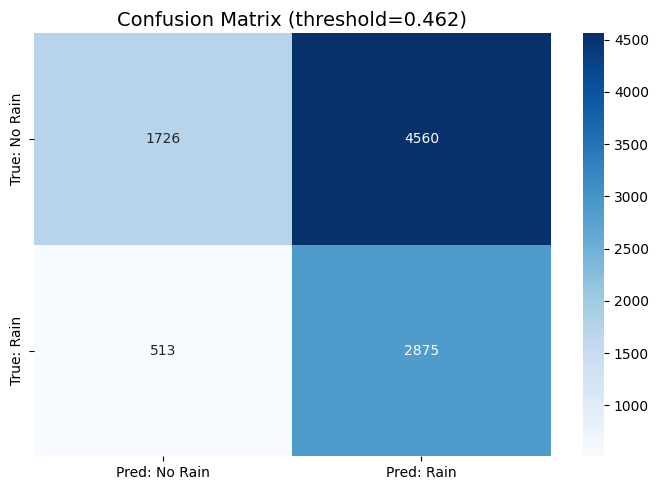

Saved → confusion_matrix_stage1.png


In [10]:
# Cell 9 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No Rain", "Pred: Rain"],
            yticklabels=["True: No Rain", "True: Rain"])
plt.title(f"Confusion Matrix (threshold={best_threshold:.3f})", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_stage1.png", dpi=150)
plt.show()
print("Saved → confusion_matrix_stage1.png")

## Step 9: ROC Curve

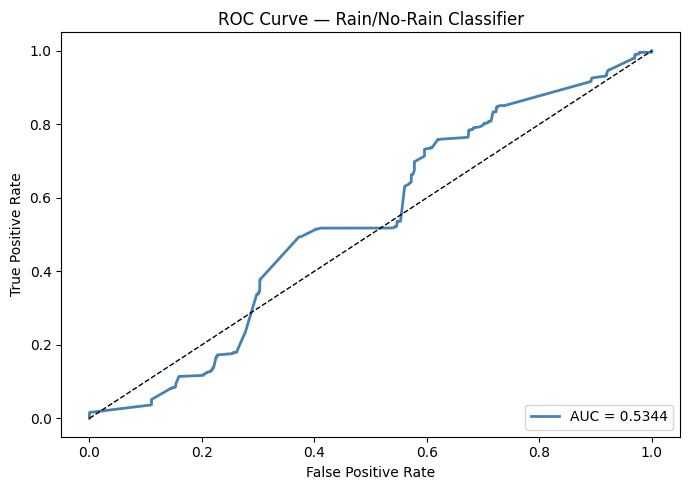

Saved → roc_curve_stage1.png


In [11]:
# Cell 10 — ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Rain/No-Rain Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve_stage1.png", dpi=150)
plt.show()
print("Saved → roc_curve_stage1.png")

## Step 10: Precision-Recall Curve

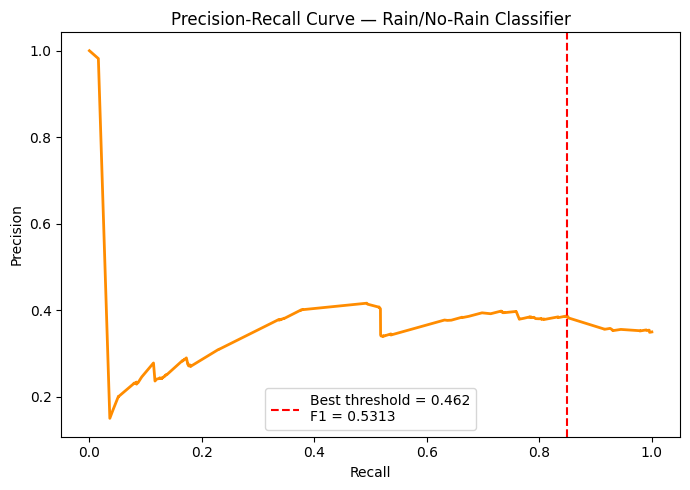

Saved → pr_curve_stage1.png


In [12]:
# Cell 11 — Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2)
plt.axvline(x=recalls[best_idx], color="red", linestyle="--",
            label=f"Best threshold = {best_threshold:.3f}\nF1 = {best_f1:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Rain/No-Rain Classifier")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_curve_stage1.png", dpi=150)
plt.show()
print("Saved → pr_curve_stage1.png")

## Step 11: Feature Importance

Top 20 Features:
             feature  importance
            zcr_mean    0.150079
  centroid_mean_mean    0.039209
   mfcc_12_mean_mean    0.039097
contrast_3_mean_mean    0.023961
    mfcc_7_mean_mean    0.019292
   centroid_mean_std    0.019263
    mfcc_1_mean_mean    0.019192
      mfcc_6_std_std    0.018518
    mfcc_10_std_mean    0.016305
    mfcc_4_mean_mean    0.015543
     mfcc_7_mean_std    0.015147
  flatness_mean_mean    0.014961
   mfcc_10_mean_mean    0.014870
contrast_4_mean_mean    0.014598
    mfcc_5_mean_mean    0.014526
     mfcc_9_std_mean    0.014509
    mfcc_2_mean_mean    0.013830
    mfcc_8_mean_mean    0.013407
 bandwidth_mean_mean    0.012824
   flatness_mean_std    0.012767


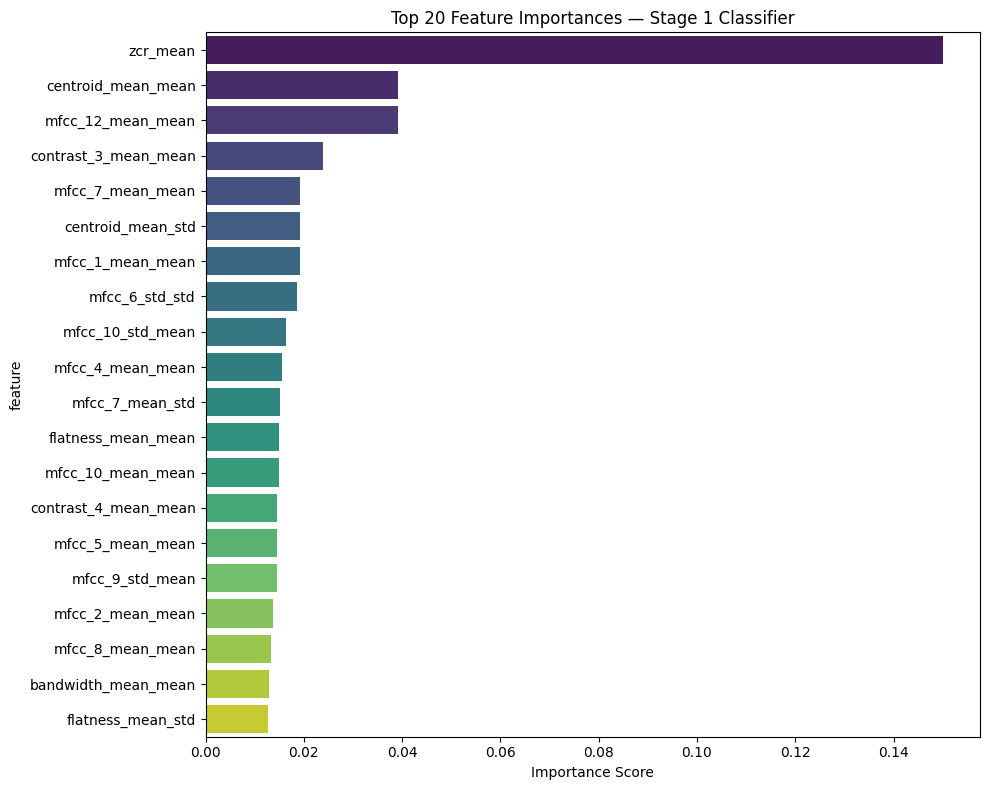

Saved → feature_importance_stage1.png


In [13]:
# Cell 12 — Feature importance
feat_imp = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 Features:")
print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importances — Stage 1 Classifier")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance_stage1.png", dpi=150)
plt.show()
print("Saved → feature_importance_stage1.png")

## Step 12: Save Model & Summary

In [14]:
# Cell 13 — Save model + summary
clf.save_model(f"{OUTPUT_DIR}/xgb_classifier_stage1.json")

with open(f"{OUTPUT_DIR}/threshold_stage1.txt", "w") as f:
    f.write(str(best_threshold))

print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Train samples  : {len(train)}")
print(f"Test samples   : {len(test)}")
print(f"Features used  : {len(FEATURE_COLS)}")
print(f"Best iteration : {clf.best_iteration}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print(f"Best F1        : {best_f1:.4f} @ threshold {best_threshold:.4f}")
print(f"Precision      : {precisions[best_idx]:.4f}")
print(f"Recall         : {recalls[best_idx]:.4f}")
print("=" * 60)
print("Stage 1 complete. Next → Stage 2 regression on rain-only samples.")
print(f"\nSaved outputs:")
print(f"  xgb_classifier_stage1.json")
print(f"  scaler_stage1.pkl")
print(f"  threshold_stage1.txt ({best_threshold:.6f})")
print(f"  confusion_matrix_stage1.png")
print(f"  roc_curve_stage1.png")
print(f"  pr_curve_stage1.png")
print(f"  feature_importance_stage1.png")

FINAL SUMMARY
Train samples  : 20921
Test samples   : 9674
Features used  : 112
Best iteration : 2
ROC-AUC        : 0.5344
Best F1        : 0.5313 @ threshold 0.4624
Precision      : 0.3867
Recall         : 0.8486
Stage 1 complete. Next → Stage 2 regression on rain-only samples.

Saved outputs:
  xgb_classifier_stage1.json
  scaler_stage1.pkl
  threshold_stage1.txt (0.462375)
  confusion_matrix_stage1.png
  roc_curve_stage1.png
  pr_curve_stage1.png
  feature_importance_stage1.png
